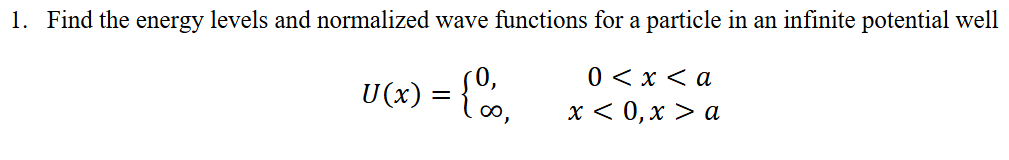

1. Infinite potential well. 

Probability must go to zero at infinity and the result is no $\psi$ outside $0$ to $a$

$$
    P(x<0) = 0
\\  P(x>a) = 0
$$
And there is no potential inside, so it's just sine
$$
    -\frac{\hbar}{2m} \psi'' = E \psi
\\ \psi'' = -\frac{2m}{\hbar}E \psi 
\\ \psi'' = -k^2\psi  
\\ \psi(x) = A \sin(kx) + B\cos(kx)
$$

$$
\\  \psi(0) = \psi(a) = 0
\\  B\cos(0) = 0 \rightarrow a = 0, 
\\  A\sin(ka) = 0 \rightarrow ka = n\pi
\\  k = \frac{n\pi}{a}
\\ \psi_n(x) = A \sin\left(\frac{n\pi x}{a}\right)
$$

Normalize so $P(0<x<a)=1$

$$
    \braket{\psi_n|\psi_n} = 1
\\ A^2\int_0^a \sin^2\left(\frac{n\pi x}{a}\right) dx = 1
\\ A^2 \frac{a}{2} = 1
\\ A = \sqrt{2/a}
\\ \psi_n(x) = \sqrt{2 \over a} \sin\left(\frac{n\pi x}{a}\right)

$$

----
some math done by sympy:

In [5]:
from sympy import *

x, a = symbols('x a')
n = symbols('n', integer=True)
integrate((sin(n*pi*x/a))**2, (x, 0, a))

Piecewise((a/2, Ne(pi*n/a, 0)), (0, True))

<div style="page-break-after: always"> </div>

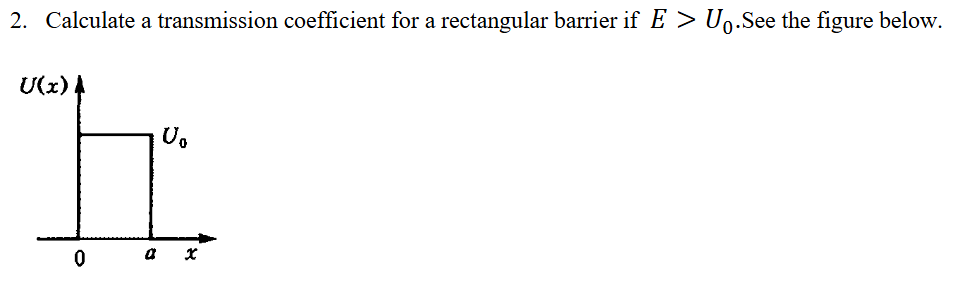

In-class adventure? Not quite since $E>U_0$

$$
\\  k^2 = \frac{2mE}{\hbar}
\\  \kappa^2 = \frac{2m(E-U_0)}{\hbar} > 0
\\  \psi'' + k^2 \psi = 0
$$

Three solutions

$$
\\  \psi_1 = Ae^{ikx} + Be^{-ikx}
\\  \psi_2 = Ce^{i\kappa x} + D e^{-\kappa x}
\\  \psi_3 =  Fe^{ikx}
\\  \psi_1(0) = \psi_2(0)
\\  A+B = C+D
\\  \psi_1'(0) = \psi_2'(0)
\\  ikA - ikB = i\kappa C - i\kappa D
\\  A - B = \frac{\kappa}{k}\left(C - D \right)
\\  C = \frac{D(\kappa - k)+2k}{\kappa + k}
$$
Let's check the other side
$$
    Fe^{ika} = C e^{i\kappa a} + D e^{-i\kappa a}
\\  F = C + De^{-i (\kappa+k) a}
\\  ikFe^{ika} = i\kappa C e^{i\kappa a} - i\kappa D e^{-i\kappa a}
\\ F = \frac{\kappa}{k} \left( C - De^{-i(\kappa+k)a} \right)
\\ C = \frac{D(\kappa+k)e^{-ia(\kappa+k)}}{\kappa-k}
$$



Fortunately, our probability current equation from in class holds here since all our wave functions are the same (just different $\kappa$)

$$
    R = \frac{|B|^2}{|A|^2}
\\  T = \frac{|E|^2}{|A|^2}
$$

$$
\frac{B}{A} = C + D - 1 = \frac{\kappa}{k} (D-C) + 1
$$

----
Some math done by sympy:

In [40]:
C, D, k, kappa, a = symbols('C D k kappa a')

# from first boundary condition
C_sol_1 = solve(Eq(C + D - 1, kappa/k * (D-C) + 1), C)[0]
display(Eq(C,C_sol_1))

# --- # 

# from second boundary condition
C_sol_2 = solve(Eq(C+D*exp(-1j*(kappa+k)*a), kappa/k*(C-D*exp(-1j*(kappa+k)*a))), C)[0]
display(Eq(C, C_sol_2))

# --- #

# enough info to find D in terms of k, kappa, and a
D_sol = solve(Eq(C_sol_1, C_sol_2), D)[0]
display(Eq(D, D_sol.simplify()))

# insert D into C_sol_1
display(Eq(C, C_sol_1.replace(D, D_sol).simplify()))

simplify(C_sol_1.replace(D, D_sol) + D_sol - 1)

Eq(C, (-D*k + D*kappa + 2*k)/(k + kappa))

Eq(C, D*(-k - kappa)*exp(-I*a*(k + kappa))/(k - kappa))

Eq(D, -2*k*(k - kappa)*exp(I*a*(k + kappa))/(-k**2*exp(I*a*(k + kappa)) + k**2 + 2*k*kappa*exp(I*a*(k + kappa)) + 2*k*kappa - kappa**2*exp(I*a*(k + kappa)) + kappa**2))

Eq(C, 2*k*(k + kappa)/(-k**2*exp(I*a*(k + kappa)) + k**2 + 2*k*kappa*exp(I*a*(k + kappa)) + 2*k*kappa - kappa**2*exp(I*a*(k + kappa)) + kappa**2))

(k**2*exp(I*a*(k + kappa)) - k**2 - kappa**2*exp(I*a*(k + kappa)) + kappa**2)/(k**2*exp(I*a*k + I*a*kappa) - k**2 - 2*k*kappa*exp(I*a*k + I*a*kappa) - 2*k*kappa + kappa**2*exp(I*a*k + I*a*kappa) - kappa**2)

<div style="page-break-after: always"> </div>

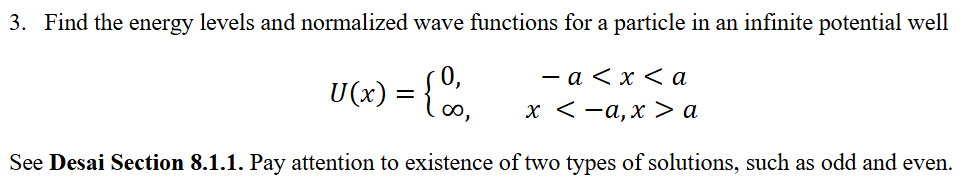

Can't we just transform from $x \rightarrow 2x-a$? It gives

$$
\psi_n(x) = \sqrt{2 \over a} \sin\left(\frac{n\pi (2x-a)}{a}\right)
          = \sqrt{2 \over a} \sin\left(\frac{2 n\pi x}{a} - n\pi\right)
$$

Not quite, unfortunately this doesn't match our desired result. Good office hours question.

New boundary condition:
$$
\\  \psi( a) =  A \sin(ka) + B \cos(ka) = 0
\\  \psi(-a) = -A \sin(ka) + B \cos(ka) = 0
A \sin(k a) =  B \cos(k a) = 0
$$
Rather than having no wavefunction, set either $\sin(ka)$ or $\cos(ka)$ to zero and remove the other function

$A = 0, \cos(k a) = 0$:

$$
    \psi(x) = B \cos(kx)
\\  \cos(ka) = 0 \rightarrow ka = \frac{n\pi}{2}
\\  k = \frac{n\pi}{2a}
\\  B^2 \int_{-a}^a \cos^2\left(\frac{n\pi}{2a}x \right) dx = B^2 a = 1
\\ B = \sqrt{1 \over a}
$$

$B = 0, \sin(k a) = 0:$

$$
    \psi(x) = A \sin(kx)
\\  ka = n \pi
\\  k = \frac{n\pi}{a}
$$

In [44]:
k = n*pi/(2*a)
integrate(cos(k*x)**2, (x,-a, a)).simplify()

Piecewise((a, Ne(pi*n/a, 0)), (2*a, True))

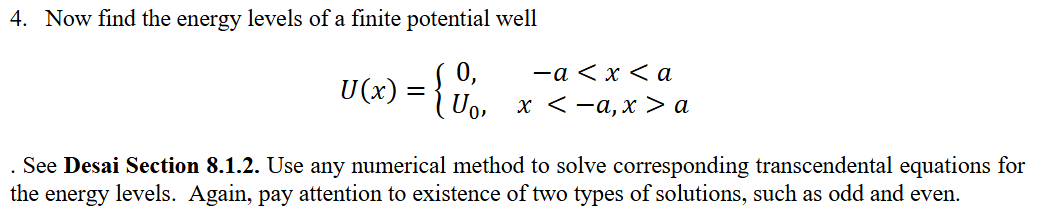